# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('tableau-colorblind10')

## 0. Load data

In [3]:
df = pd.read_csv('Data/EDA_data-FULL.csv')
df.head()

,Apikey,URL,Title,text,Publish_date,Authors,Section,User_Needs,Views,Avg. views,Engaged minutes,Avg. minutes,Desktop views,Mobile views,Tablet views
0,"pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/09/gray-inv...,Gray investigated for buying $1.25M fire truck...,Federal and local law enforcement are investig...,2026-01-09 08:55:00,Rory Sweeting,News,update-me,109875,1.084,31960.0,0.315,3910.0,104307.0,1658.0
1,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/03/06/social-...,Social Security now requires Maine parents to ...,"An update, in which the Social Security Admini...",2025-03-06 17:14:00,Joe Lawlor,News,none,98329,1.109,64495.0,0.727,9783.0,86241.0,2305.0
2,"centralmaine.com, pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/28/ice-agen...,"ICE agents shatter window, leave 1-month-old b...","PORTLAND — Hassane Barry and his wife, Nene, b...",2026-01-28 17:43:00,"Dylan Tusinski,Salomé Cloteaux",News,give-me-perspective,76168,1.145,84939.0,1.277,12634.0,61819.0,1715.0
3,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/02/05/maine-m...,Maine Mall shooting: Police search for suspect...,SOUTH PORTLAND — Police are searching for a pe...,2025-02-05 16:21:00,"Daniel Kool,Morgan Womack",News,none,73901,1.341,38065.0,0.691,14806.0,58483.0,612.0
4,"centralmaine.com, pressherald.com, sunjournal.com",http://www.pressherald.com/2025/10/21/graham-p...,Graham Platner says he will remove a Nazi-link...,A leading Democratic candidate for U.S. Senate...,2025-10-21 12:27:00,Randy Billings,Politics,educate-me,62651,1.158,29502.0,0.545,16738.0,45454.0,459.0


## 1. Visualize Data

In [4]:
df['Publish_year'] = df.Publish_date.apply(lambda x : x[:4])
df['Publish_month'] = df.Publish_date.apply(lambda x : x[:7])
df['Publish_day'] = df.Publish_date.apply(lambda x : x[:10])
df[['Publish_date','Publish_year','Publish_month','Publish_day']].head()

,Publish_date,Publish_year,Publish_month,Publish_day
0,2026-01-09 08:55:00,2026,2026-01,2026-01-09
1,2025-03-06 17:14:00,2025,2025-03,2025-03-06
2,2026-01-28 17:43:00,2026,2026-01,2026-01-28
3,2025-02-05 16:21:00,2025,2025-02,2025-02-05
4,2025-10-21 12:27:00,2025,2025-10,2025-10-21


In [11]:
CLASS_COLORS = {
    "update-me": "#9962b4ff",
    "give-me-perspective": "#83b37fff",
    "educate-me": "#e3c375ff",
    "connect-me": "#bb6861ff",
    "inspire-me": "#7493e3ff",
    "help-me": "#87c0c1ff",
    "none": "#818181",
}
color_list = list(CLASS_COLORS.values())
print(color_list)

['#9962b4ff', '#83b37fff', '#e3c375ff', '#bb6861ff', '#7493e3ff', '#87c0c1ff', '#818181']


In [15]:
from matplotlib.colors import LinearSegmentedColormap
cm = LinearSegmentedColormap.from_list(name='METLN',colors=color_list)

In [18]:
df.groupby(['Publish_month','User_Needs']).URL.count().rename('# of Publications').unstack()[CLASS_COLORS.keys()]

User_Needs,update-me,give-me-perspective,educate-me,connect-me,inspire-me,help-me,none
Publish_month,,,,,,,
2025-02,NaN,NaN,NaN,NaN,NaN,NaN,686.0
2025-03,NaN,NaN,NaN,NaN,NaN,NaN,736.0
2025-04,NaN,NaN,NaN,NaN,NaN,NaN,676.0
2025-05,NaN,NaN,NaN,NaN,NaN,NaN,618.0
2025-06,NaN,NaN,NaN,NaN,NaN,NaN,638.0
2025-07,NaN,NaN,NaN,NaN,NaN,NaN,652.0
2025-08,1.0,NaN,NaN,1.0,NaN,NaN,603.0
2025-09,268.0,141.0,102.0,37.0,32.0,15.0,89.0
2025-10,331.0,106.0,107.0,60.0,36.0,25.0,26.0


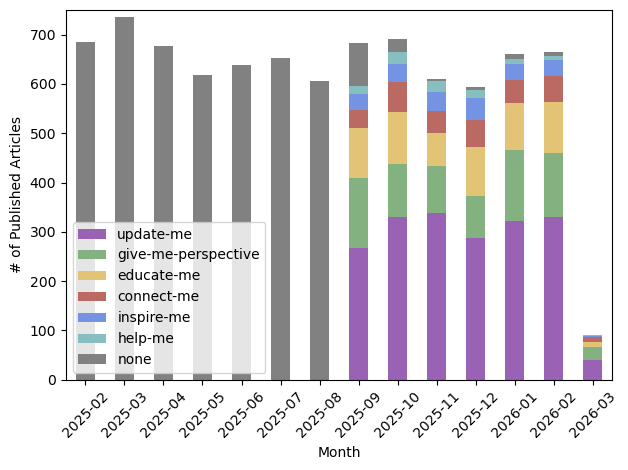

In [ ]:
df.groupby(['Publish_month','User_Needs']).URL.count().rename('# of Publications').unstack()[CLASS_COLORS.keys()].plot(kind='bar',stacked=True,colormap=cm)
ax = plt.gca()
ax.set_xticklabels(df.Publish_month.sort_values().unique(), rotation=45)
ax.set(ylim=[0,750],xlabel='Month',ylabel='# of Published Articles')
ax.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('publish_month_stack.png', dpi=300)
plt.show()

In [6]:
for i in range(10):
    art = df.text[i]
    words = art.split(' ')
    print(i, len(words))

0 655
1 816
2 991
3 942
4 933
5 1431
6 5
7 723
8 654
9 1010


In [7]:
# df[['Title','URL','text']].iloc[6,:]
art = df.iloc[89,:]
print(art.Title,art.URL,art.User_Needs)

4 maps show how much snow Maine forecasters expect Tuesday http://www.sunjournal.com/2025/12/01/4-maps-show-much-snow-local-forecasters-expect-tuesday/ update-me


## 2. Load Semantic Embedding

In [11]:
import h5py
embed_f = h5py.File('Data/semantic_embeddings.h5','r')
print('datasets: ',list(embed_f.keys()))

datasets:  ['URL', 'classification_embedding', 'cluster_embedding']


In [13]:
url_emb = embed_f['URL']
cluster_emb = embed_f['cluster_embedding']

print(url_emb.shape,cluster_emb.shape)

(8606,) (8606, 768)


In [17]:
url_arr = np.array(url_emb, dtype=str)
embed_arr = np.array(cluster_emb)

In [23]:
# filter out very short articles
min_word_count = 50
word_count_mask = [len(text.split(' ')) > min_word_count for text in df.text]

df_masked = df[word_count_mask].reset_index(drop=True)
url_masked = url_arr[word_count_mask]
embed_masked = embed_arr[word_count_mask]
print(embed_masked.shape)

(8484, 768)


In [29]:
# split into labeled/unlabeled

user_needs = df_masked.User_Needs.to_numpy()

unlabeled_mask = user_needs == 'none'
labeled_mask = ~unlabeled_mask

df_labeled = df_masked[labeled_mask].reset_index(drop=True)
df_unlabeled = df_masked[unlabeled_mask].reset_index(drop=True)
url_labeled = url_masked[labeled_mask]
url_unlabeled = url_masked[unlabeled_mask]
embed_labeled = embed_masked[labeled_mask]
embed_unlabeled = embed_masked[unlabeled_mask]

In [32]:
print(df_labeled.shape, df_unlabeled.shape, url_labeled.shape, url_unlabeled.shape,
      embed_labeled.shape, embed_unlabeled.shape) # checking that the filters have left equivalent samples

(3802, 18) (4682, 18) (3802,) (4682,) (3802, 768) (4682, 768)


## 3. clustering labeled articles

In [34]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

n_clusters = len(df_labeled.User_Needs.unique())

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(embed_labeled)
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(embed_labeled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [37]:
df_labeled.User_Needs.unique()

<StringArray>
[          'update-me', 'give-me-perspective',          'educate-me',
          'connect-me',             'help-me',          'inspire-me']
Length: 6, dtype: str

In [42]:
# label encode user needs
label_map = dict(zip(df_labeled.User_Needs.unique(),np.arange(6)))
user_encoded = df_labeled.User_Needs.map(label_map).to_numpy()
print(label_map,list(df_labeled.User_Needs[:5]),user_encoded[:5])

{'update-me': np.int64(0), 'give-me-perspective': np.int64(1), 'educate-me': np.int64(2), 'connect-me': np.int64(3), 'help-me': np.int64(4), 'inspire-me': np.int64(5)} ['update-me', 'give-me-perspective', 'educate-me', 'update-me', 'update-me'] [0 1 2 0 0]


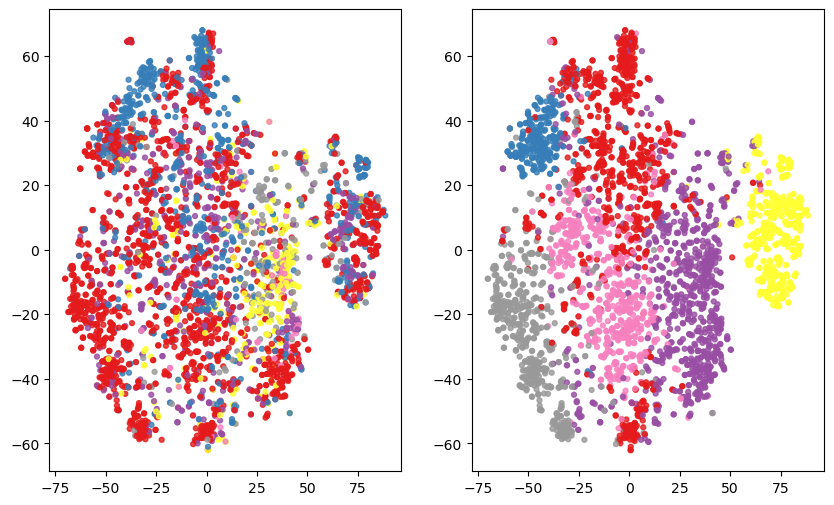

In [47]:
fig, axs = plt.subplots(1,2,figsize=(10,6))

# first, scatter with their original labels
axs[0].scatter(X_tsne[:,0],X_tsne[:,1],marker='.',c=user_encoded,cmap='Set1',s=50,alpha=.8)

# second, scatter with clusters
axs[1].scatter(X_tsne[:,0],X_tsne[:,1],marker='.',c=kmeans.labels_,cmap='Set1',s=50,alpha=.8)

plt.show()

In [49]:
from umap import UMAP

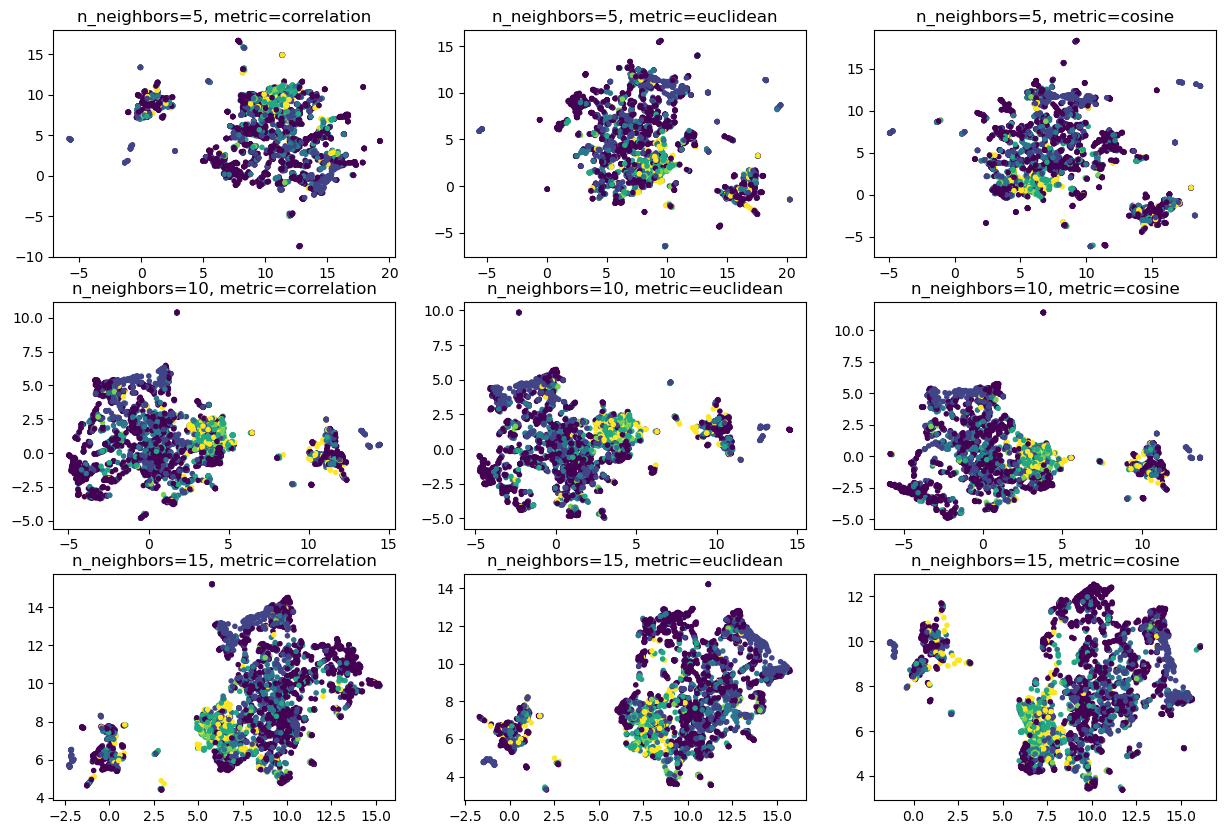

In [51]:
# make a grid of plots doing UMAP with different n_neighbors and metric parameters

figumap, axumap = plt.subplots(3, 3, figsize=(15, 10))

# axumap = axumap.flatten()
n_neighbors_list = [5, 10, 15]
metric_list = ['correlation', 'euclidean', 'cosine']
for i in range(3):
  n_neighbors = n_neighbors_list[i]
  for j in range(3):
    metric = metric_list[j]
    umap_model = UMAP(n_neighbors=n_neighbors, metric=metric)
    X_umap = umap_model.fit_transform(embed_labeled)
    axumap[i,j].scatter(X_umap[:, 0], X_umap[:, 1], marker='.', c=user_encoded)
    axumap[i,j].set_title(f'n_neighbors={n_neighbors}, metric={metric}')

plt.show()